# SHBT 261 AI in Medicine Mini Project 1

**Harvard University**\
**Spring 2026**\
**Instructors**: Mengyu Wang and Tobias Elze\
**Name**: Cindy Sun

<hr style="height:2pt">

In [8]:
# ── Imports ────────────────────────────────────────────────────────────────

# Standard Library
import os
import time
import copy

# Data & Math
import numpy as np
import pandas as pd
from pathlib import Path

# Image Processing
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray

# Progress Bar
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from IPython.display import display

# Classical ML
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

# Deep Learning — PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Deep Learning — timm (ViT)
import timm

# Serialization
import joblib

print("All imports OK ✓")
print(f"PyTorch version : {torch.__version__}")
print(f"timm version    : {timm.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"MPS available   : {torch.backends.mps.is_available()}")

All imports OK ✓
PyTorch version : 2.4.1
timm version    : 1.0.25
CUDA available  : False
MPS available   : True


In [9]:
# ── Project Paths ──────────────────────────────────────────────────────────
PROJECT_DIR = Path("/Users/cindysun/Desktop/SHBT261_miniproject1")
DATA_DIR    = PROJECT_DIR / "data" / "caltech-101"
FIG_DIR     = PROJECT_DIR / "figures"
MODEL_DIR   = PROJECT_DIR / "models"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT_DIR}")
print(f"Data    : {DATA_DIR}")
print(f"Data exists: {DATA_DIR.exists()}")


Project : /Users/cindysun/Desktop/SHBT261_miniproject1
Data    : /Users/cindysun/Desktop/SHBT261_miniproject1/data/caltech-101
Data exists: True


In [10]:
import os
print("Current working directory:", os.getcwd())
print("\nContents:")
print(os.listdir(os.getcwd()))

Current working directory: /Users/cindysun/Desktop/SHBT261_miniproject1

Contents:
['svm_model.pkl', '.DS_Store', 'shbt261_cindysun_mini_proj1.ipynb', 'models', 'Mini-Project 1.pdf', 'cindysun_mini_proj1.ipynb', 'figures', '.virtual_documents', '.venv', 'svm_scaler.pkl', '.ipynb_checkpoints', 'cindysun_mini_proj1-draft1.ipynb', '.git', 'data', 'resnet50_caltech101.pth']


Found 101 classes
First 10: ['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass']

Total images: 8677
Sample entry: (PosixPath('/Users/cindysun/Desktop/SHBT261_miniproject1/data/caltech-101/Faces/image_0146.jpg'), 0, 'Faces')


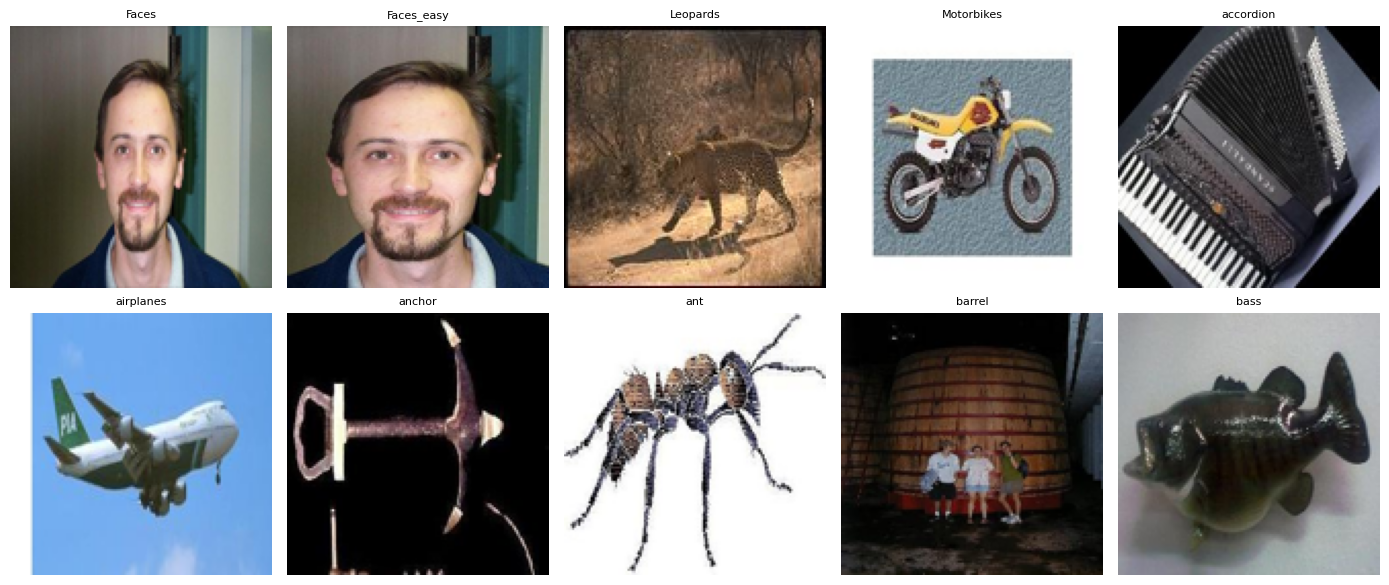

In [11]:
# ── 2. Discover all classes (sub-folders) ──────────────────────────────────
# filter to exclude hidden/system folders
classes = sorted([
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and not d.name.startswith('.')  # excludes .ipynb_checkpoints
])

class_to_idx = {cls: i for i, cls in enumerate(classes)}

print(f"Found {len(classes)} classes")
print("First 10:", classes[:10])


# ── 3. Build a flat list of (image_path, label_index, class_name) ──────────
dataset = []
for cls in classes:
    for img_path in (DATA_DIR / cls).glob("*.jpg"):
        dataset.append((img_path, class_to_idx[cls], cls))

print(f"\nTotal images: {len(dataset)}")
print("Sample entry:", dataset[0])

# ── 4. Quick sanity check – open one image per class ──────────────────────
def load_image(path, size=(128, 128)):
    img = Image.open(path).convert("RGB").resize(size)
    return np.array(img)

# Show a few sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_classes = classes[:10]
for ax, cls in zip(axes.flat, sample_classes):
    sample_path = next((DATA_DIR / cls).glob("*.jpg"))
    ax.imshow(load_image(sample_path))
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
df_check = pd.DataFrame(dataset, columns=["image_path", "label_index", "class_name"])
df_check.head(10)

,image_path,label_index,class_name
0,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
1,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
2,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
3,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
4,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
5,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
6,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
7,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
8,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces
9,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,0,Faces


In [13]:
# ── 1. Build DataFrame ─────────────────────────────────────────────────────

records = []
for cls_folder in sorted(DATA_DIR.iterdir()):
    if cls_folder.is_dir():
        for img_path in cls_folder.glob("*.jpg"):
            records.append({"image_path": str(img_path), "class_name": cls_folder.name})

df = pd.DataFrame(records)

# Encode string labels → integers
le = LabelEncoder()
df["label"] = le.fit_transform(df["class_name"])

print(f"Total images : {len(df)}")
print(f"Total classes: {df['label'].nunique()}")
df.head()

Total images : 8677
Total classes: 101


,image_path,class_name,label
0,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,Faces,0
1,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,Faces,0
2,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,Faces,0
3,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,Faces,0
4,/Users/cindysun/Desktop/SHBT261_miniproject1/d...,Faces,0


In [14]:
# ── 2. Stratified split 70 / 15 / 15 ──────────────────────────────────────
# First split off 70% train
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Split the remaining 30% equally into val and test (15% each)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):>5} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df):>5} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df):>5} images ({len(test_df)/len(df)*100:.1f}%)")

Train :  6073 images (70.0%)
Val   :  1302 images (15.0%)
Test  :  1302 images (15.0%)


In [15]:
# ── 3a. For Classical ML → flat numpy arrays with HOG features ─────────────
IMG_SIZE = (128, 128)

def extract_hog(img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_gray = rgb2gray(np.array(img))
    features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), feature_vector=True)
    return features

def build_ml_arrays(dataframe):
    X, y = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        X.append(extract_hog(row["image_path"]))
        y.append(row["label"])
    return np.array(X, dtype=np.float32), np.array(y)

# ── Load if already saved, otherwise extract and save ─────────────────────
if (MODEL_DIR / "X_train_ml.npy").exists():
    print("HOG arrays found on Drive — loading...")
    X_train_ml = np.load(MODEL_DIR / "X_train_ml.npy")
    y_train_ml = np.load(MODEL_DIR / "y_train_ml.npy")
    X_val_ml   = np.load(MODEL_DIR / "X_val_ml.npy")
    y_val_ml   = np.load(MODEL_DIR / "y_val_ml.npy")
    X_test_ml  = np.load(MODEL_DIR / "X_test_ml.npy")
    y_test_ml  = np.load(MODEL_DIR / "y_test_ml.npy")
    print("Loaded ✓")

else:
    print("HOG arrays not found — extracting (first time only)...")
    X_train_ml, y_train_ml = build_ml_arrays(train_df)
    X_val_ml,   y_val_ml   = build_ml_arrays(val_df)
    X_test_ml,  y_test_ml  = build_ml_arrays(test_df)

    np.save(MODEL_DIR / "X_train_ml.npy", X_train_ml)
    np.save(MODEL_DIR / "y_train_ml.npy", y_train_ml)
    np.save(MODEL_DIR / "X_val_ml.npy",   X_val_ml)
    np.save(MODEL_DIR / "y_val_ml.npy",   y_val_ml)
    np.save(MODEL_DIR / "X_test_ml.npy",  X_test_ml)
    np.save(MODEL_DIR / "y_test_ml.npy",  y_test_ml)
    print("Extracted and saved to Drive ✓")

print(f"X_train shape : {X_train_ml.shape}")
print(f"X_val shape   : {X_val_ml.shape}")
print(f"X_test shape  : {X_test_ml.shape}")

HOG arrays found on Drive — loading...
Loaded ✓
X_train shape : (6073, 8100)
X_val shape   : (1302, 8100)
X_test shape  : (1302, 8100)


In [16]:
# ── 3b. For Deep Learning → PyTorch DataLoaders ────────────────────────────
DL_IMG_SIZE = 224    # standard size for pretrained models
BATCH_SIZE  = 32

dl_transform = {
    "train": transforms.Compose([
        transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
        transforms.RandomHorizontalFlip(),          # simple augmentation
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], # ImageNet mean/std
                             [0.229, 0.224, 0.225])
    ]),
    "val_test": transforms.Compose([
        transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

class Caltech101Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, row["label"]

train_loader = DataLoader(
    Caltech101Dataset(train_df, dl_transform["train"]),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
val_loader = DataLoader(
    Caltech101Dataset(val_df,   dl_transform["val_test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    Caltech101Dataset(test_df,  dl_transform["val_test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

# Quick check
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # (32, 3, 224, 224)
print(f"Labels shape: {labels.shape}")   # (32,)

Batch shape : torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## Model 1: Classical ML - SVM + HOG features

In [17]:
# ── SVM + HOG: Full Pipeline ───────────────────────────────────────────────

if (MODEL_DIR / "svm_model.pkl").exists():
    print("SVM model found on Drive — loading...")
    svm    = joblib.load(MODEL_DIR / "svm_model.pkl")
    scaler = joblib.load(MODEL_DIR / "svm_scaler.pkl")

    # Still need scaled arrays for evaluation cells
    X_train_sc = scaler.transform(X_train_ml)
    X_val_sc   = scaler.transform(X_val_ml)
    X_test_sc  = scaler.transform(X_test_ml)
    print("Loaded ✓")

else:
    print("SVM model not found — training (first time only)...")

    # ── 1. Scale features ─────────────────────────────────────────────────
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_ml)   # fit only on train!
    X_val_sc   = scaler.transform(X_val_ml)
    X_test_sc  = scaler.transform(X_test_ml)

    # ── 2. Train SVM ──────────────────────────────────────────────────────
    svm = SVC(kernel="rbf", C=10, gamma="scale",
              probability=True,
              random_state=42)
    svm.fit(X_train_sc, y_train_ml)

    # ── 3. Save immediately ───────────────────────────────────────────────
    joblib.dump(svm,    MODEL_DIR / "svm_model.pkl")
    joblib.dump(scaler, MODEL_DIR / "svm_scaler.pkl")
    print("Trained and saved to Drive ✓")

SVM model found on Drive — loading...


/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded ✓


In [18]:
# ── Predictions ────────────────────────────────────────────────────────────
if (MODEL_DIR / "svm_test_pred.npy").exists():
    print("Predictions found on Drive — loading...")
    y_val_pred  = np.load(MODEL_DIR / "svm_val_pred.npy")
    y_test_pred = np.load(MODEL_DIR / "svm_test_pred.npy")
    y_test_prob = np.load(MODEL_DIR / "svm_test_prob.npy")
    print("Loaded ✓")

else:
    print("Running predictions (first time only)...")
    y_val_pred  = svm.predict(X_val_sc)
    y_test_pred = svm.predict(X_test_sc)
    y_test_prob = svm.predict_proba(X_test_sc)

    np.save(MODEL_DIR / "svm_val_pred.npy",  y_val_pred)
    np.save(MODEL_DIR / "svm_test_pred.npy", y_test_pred)
    np.save(MODEL_DIR / "svm_test_prob.npy", y_test_prob)
    print("Predictions saved to Drive ✓")

Predictions found on Drive — loading...
Loaded ✓


In [19]:
# ── 4. Core Metrics ────────────────────────────────────────────────────────
assert len(y_test_ml) == len(y_test_pred), \
    f"Shape mismatch: y_test_ml={len(y_test_ml)}, y_test_pred={len(y_test_pred)}"

test_acc = accuracy_score(y_test_ml, y_test_pred)
print(f"{'='*50}")
print(f"  SVM + HOG  —  Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc*100:.2f}%")

# Top-5 Accuracy
top5 = top_k_accuracy_score(y_test_ml, y_test_prob, k=5)
print(f"  Top-5 Accuracy   : {top5*100:.2f}%")

print(f"\n{'─'*50}")
print(classification_report(
    y_test_ml, y_test_pred,
    target_names=le.classes_,
    digits=3,
    zero_division=0
))

  SVM + HOG  —  Test Results
  Overall Accuracy : 65.59%
  Top-5 Accuracy   : 82.26%

──────────────────────────────────────────────────
                 precision    recall  f1-score   support

          Faces      0.602     0.985     0.747        66
     Faces_easy      1.000     0.985     0.992        66
       Leopards      0.545     1.000     0.706        30
     Motorbikes      0.968     1.000     0.984       120
      accordion      1.000     1.000     1.000         8
      airplanes      0.778     0.992     0.872       120
         anchor      0.000     0.000     0.000         6
            ant      0.000     0.000     0.000         6
         barrel      1.000     0.286     0.444         7
           bass      0.000     0.000     0.000         8
         beaver      0.000     0.000     0.000         7
      binocular      0.000     0.000     0.000         5
         bonsai      0.520     0.684     0.591        19
          brain      0.394     0.867     0.542        15
   bron

In [20]:
# ── 5. Per-class Accuracy ──────────────────────────────────────────────────
cm = confusion_matrix(y_test_ml, y_test_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class"          : le.classes_,
    "per_class_acc"  : per_class_acc
}).sort_values("per_class_acc", ascending=False)

print("Top 10 best recognised classes:")
print(per_class_df.head(10).to_string(index=False))
print("\nTop 10 worst recognised classes:")
print(per_class_df.tail(10).to_string(index=False))

Top 10 best recognised classes:
      class  per_class_acc
     buddha       1.000000
   Leopards       1.000000
 Motorbikes       1.000000
  accordion       1.000000
  trilobite       1.000000
   car_side       1.000000
  airplanes       0.991667
      Faces       0.984848
 Faces_easy       0.984848
grand_piano       0.933333

Top 10 worst recognised classes:
     class  per_class_acc
    cannon            0.0
strawberry            0.0
      bass            0.0
  hedgehog            0.0
     panda            0.0
 binocular            0.0
    snoopy            0.0
   lobster            0.0
  nautilus            0.0
       ant            0.0


SVM confusion matrix found — loading...


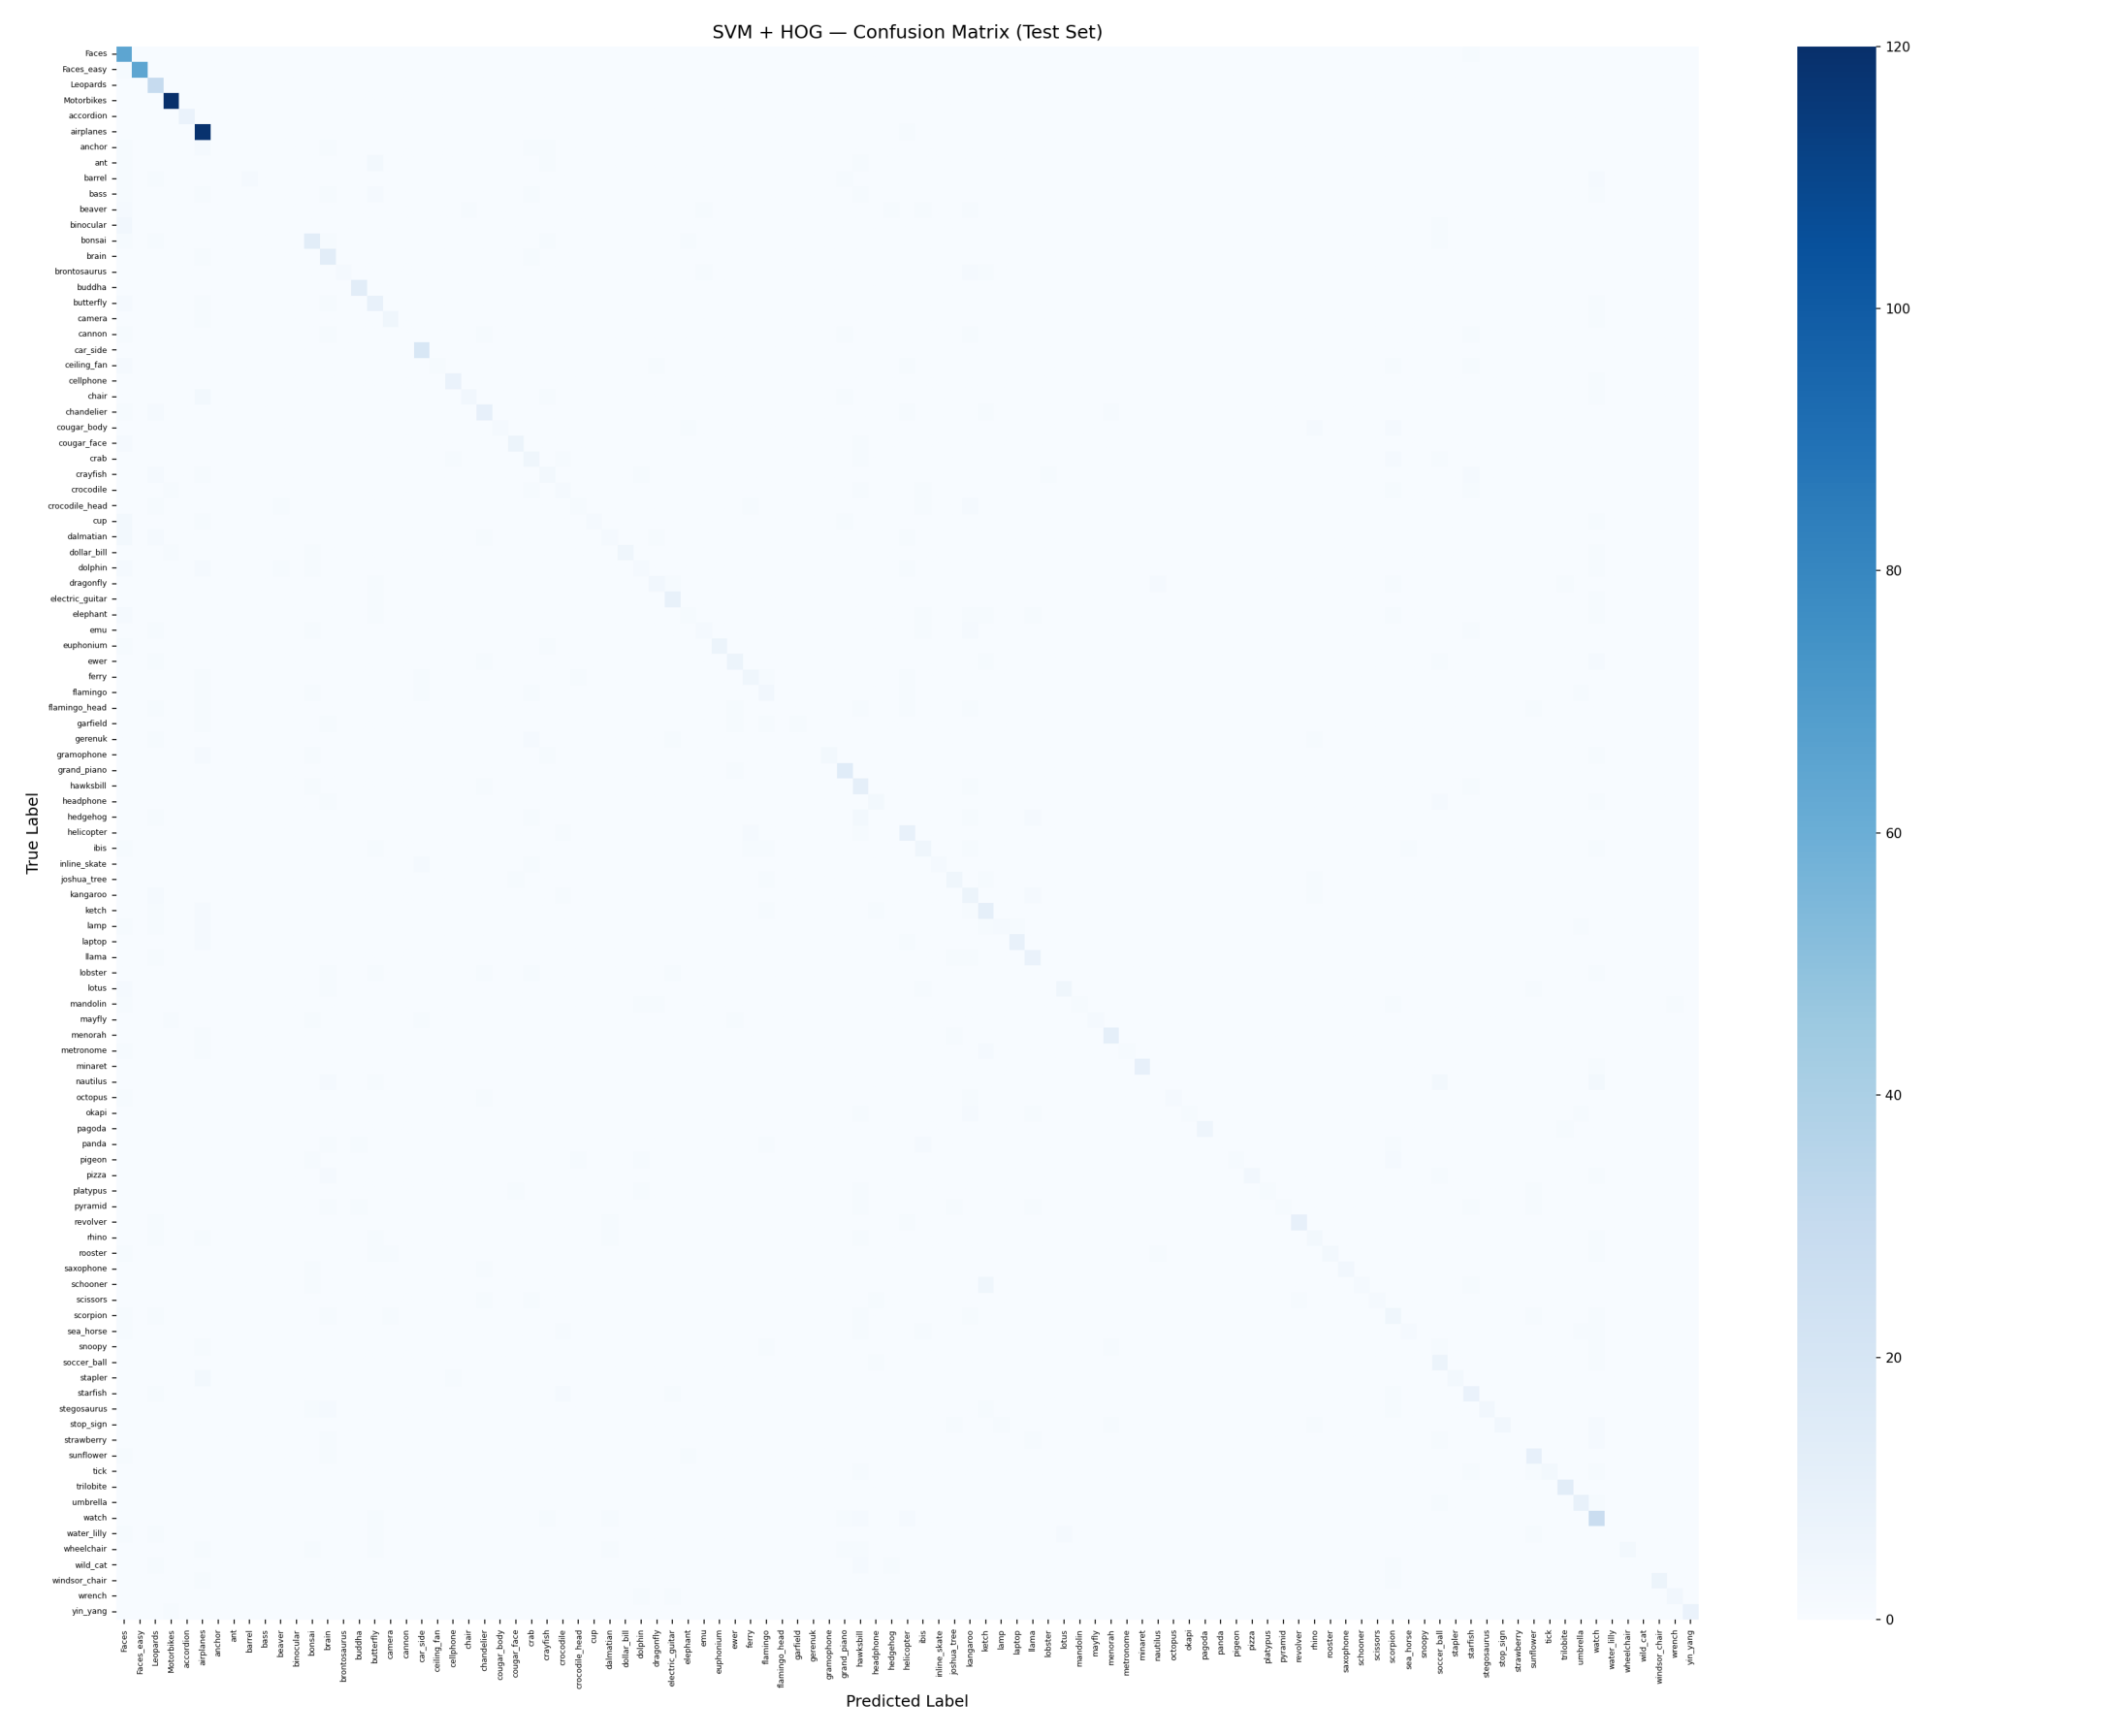

In [21]:
# ── 6. Confusion Matrix Plot ───────────────────────────────────────────────
if (FIG_DIR / "svm_confusion_matrix.png").exists():
    print("SVM confusion matrix found — loading...")
    img = mpimg.imread(FIG_DIR / "svm_confusion_matrix.png")
    fig, ax = plt.subplots(figsize=(22, 18))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(22, 18))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title("SVM + HOG — Confusion Matrix (Test Set)", fontsize=14)
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0,  fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "svm_confusion_matrix.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

SVM per-class accuracy figure found — loading...


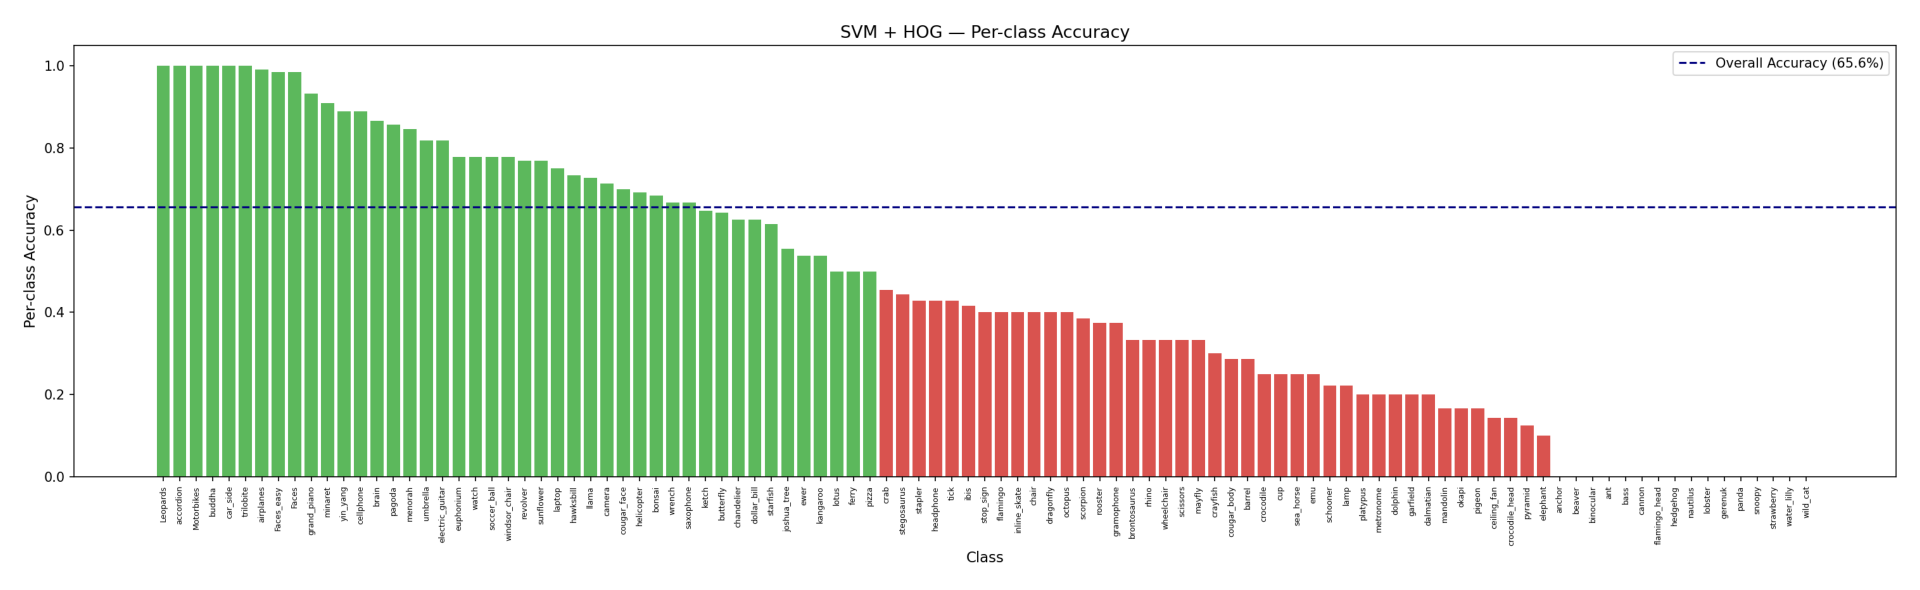

In [22]:
# ── 7. Per-class Accuracy Bar Chart ───────────────────────────────────────

# Always recompute (fast)
cm            = confusion_matrix(y_test_ml, y_test_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df  = pd.DataFrame({
    "class"        : le.classes_,
    "per_class_acc": per_class_acc
}).sort_values("per_class_acc", ascending=False)

if (FIG_DIR / "svm_per_class_accuracy.png").exists():
    print("SVM per-class accuracy figure found — loading...")
    img = mpimg.imread(FIG_DIR / "svm_per_class_accuracy.png")
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(20, 6))
    colors = ["#d9534f" if v < 0.5 else "#5cb85c" for v in per_class_df["per_class_acc"]]
    ax.bar(per_class_df["class"], per_class_df["per_class_acc"], color=colors)
    ax.axhline(test_acc, color="navy", linestyle="--", linewidth=1.5,
               label=f"Overall Accuracy ({test_acc*100:.1f}%)")
    ax.set_xlabel("Class", fontsize=11)
    ax.set_ylabel("Per-class Accuracy", fontsize=11)
    ax.set_title("SVM + HOG — Per-class Accuracy", fontsize=13)
    ax.legend()
    plt.xticks(rotation=90, fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "svm_per_class_accuracy.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

Ablation A figure found — loading...


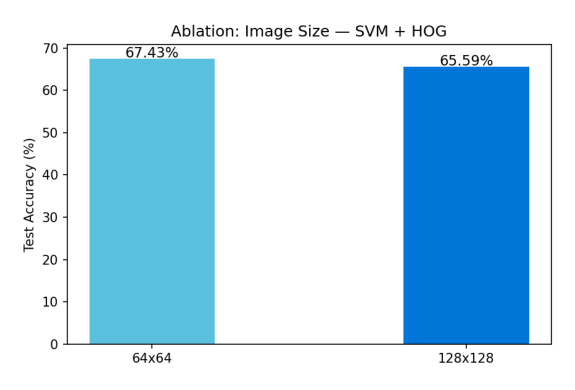

In [23]:
# ── 8. Ablation Study A: Image size 64x64 vs 128x128 ──────────────────────
if (FIG_DIR / "svm_ablation_imgsize.png").exists():
    print("Ablation A figure found — loading...")
    img = mpimg.imread(FIG_DIR / "svm_ablation_imgsize.png")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    print("Running Ablation A (first time only)...")

    def extract_hog_custom(img_path, size):
        img = Image.open(img_path).convert("RGB").resize(size)
        img_gray = rgb2gray(np.array(img))
        return hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), feature_vector=True)

    def build_features(dataframe, size):
        X, y = [], []
        for _, row in dataframe.iterrows():
            X.append(extract_hog_custom(row["image_path"], size))
            y.append(row["label"])
        return np.array(X, dtype=np.float32), np.array(y)

    ablation_results = {}

    for img_size in [(64, 64), (128, 128)]:
        print(f"Running ablation: image size {img_size}...")
        X_tr, y_tr = build_features(train_df, img_size)
        X_te, y_te = build_features(test_df,  img_size)

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        clf = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
        clf.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, clf.predict(X_te))
        ablation_results[f"{img_size[0]}x{img_size[1]}"] = acc
        print(f"  Accuracy: {acc*100:.2f}%")

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(ablation_results.keys(), [v*100 for v in ablation_results.values()],
           color=["#5bc0de", "#0275d8"], width=0.4)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("Ablation: Image Size — SVM + HOG")
    for i, (k, v) in enumerate(ablation_results.items()):
        ax.text(i, v*100 + 0.3, f"{v*100:.2f}%", ha="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "svm_ablation_imgsize.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

Ablation B figure found — loading...


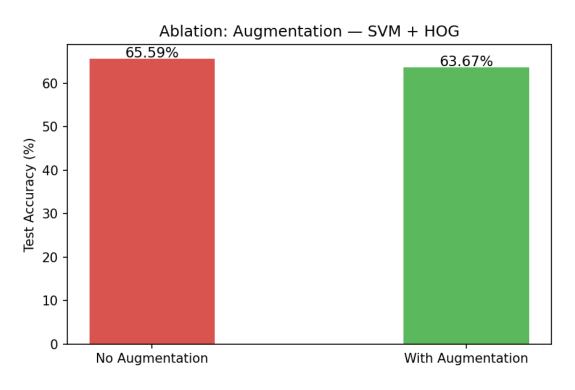

In [24]:
# ── 9. Ablation Study B: With vs Without Data Augmentation ────────────────
if (FIG_DIR / "svm_ablation_augmentation.png").exists():
    print("Ablation B figure found — loading...")
    img = mpimg.imread(FIG_DIR / "svm_ablation_augmentation.png")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    print("Running Ablation B (first time only)...")

    def augment_and_extract(dataframe, size=(128, 128)):
        X, y = [], []
        for _, row in dataframe.iterrows():
            img = Image.open(row["image_path"]).convert("RGB").resize(size)

            # Original
            gray = rgb2gray(np.array(img))
            X.append(hog(gray, orientations=9, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2), feature_vector=True))
            y.append(row["label"])

            # Flipped
            gray_flip = rgb2gray(np.array(img.transpose(Image.FLIP_LEFT_RIGHT)))
            X.append(hog(gray_flip, orientations=9, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2), feature_vector=True))
            y.append(row["label"])

        return np.array(X, dtype=np.float32), np.array(y)

    aug_results = {}

    # Without augmentation
    clf_no_aug = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
    clf_no_aug.fit(X_train_sc, y_train_ml)
    aug_results["No Augmentation"] = accuracy_score(y_test_ml,
                                        clf_no_aug.predict(X_test_sc))
    print(f"  No Augmentation Accuracy : {aug_results['No Augmentation']*100:.2f}%")

    # With augmentation
    print("Extracting augmented features...")
    X_aug, y_aug = augment_and_extract(train_df)
    sc_aug     = StandardScaler()
    X_aug_sc   = sc_aug.fit_transform(X_aug)
    X_test_aug = sc_aug.transform(X_test_ml)

    clf_aug = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
    clf_aug.fit(X_aug_sc, y_aug)
    aug_results["With Augmentation"] = accuracy_score(y_test_ml,
                                          clf_aug.predict(X_test_aug))
    print(f"  With Augmentation Accuracy: {aug_results['With Augmentation']*100:.2f}%")

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(aug_results.keys(), [v*100 for v in aug_results.values()],
           color=["#d9534f", "#5cb85c"], width=0.4)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("Ablation: Augmentation — SVM + HOG")
    for i, (k, v) in enumerate(aug_results.items()):
        ax.text(i, v*100 + 0.3, f"{v*100:.2f}%", ha="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "svm_ablation_augmentation.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

## Model 2: ResNet-50 (Transfer Learning)

In [25]:
# ── ResNet-50 Transfer Learning: Setup ────────────────────────────────────
DEVICE     = torch.device("mps" if torch.backends.mps.is_available()   # Apple Silicon
                     else "cuda" if torch.cuda.is_available()           # NVIDIA GPU
                     else "cpu")                                        # fallback
NUM_CLASSES = len(le.classes_)   # 101
print(f"Using device : {DEVICE}")
print(f"Num classes  : {NUM_CLASSES}")

Using device : mps
Num classes  : 101


In [26]:
# ── Build ResNet-50 Model ──────────────────────────────────────────────────
def build_resnet(num_classes, freeze_backbone=True):
    model = models.resnet50(weights="IMAGENET1K_V1")   # pretrained weights

    if freeze_backbone:
        # Freeze all layers except the final classifier
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer to match our 101 classes
    in_features = model.fc.in_features       # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

resnet = build_resnet(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

# Count trainable parameters
total     = sum(p.numel() for p in resnet.parameters())
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")   # only the new FC layer

Total params    : 23,714,981
Trainable params: 206,949


In [27]:
# ── Training Function ──────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=20, device=DEVICE):

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        t0 = time.time()

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            loader = train_loader if phase == "train" else val_loader

            running_loss, running_correct = 0.0, 0

            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss    += loss.item() * images.size(0)
                running_correct += (preds == labels).sum().item()

            epoch_loss = running_loss    / len(loader.dataset)
            epoch_acc  = running_correct / len(loader.dataset)
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())

        if scheduler:
            scheduler.step()

        elapsed = time.time() - t0
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {history['train_loss'][-1]:.4f}  Acc: {history['train_acc'][-1]*100:.2f}%  | "
              f"Val Loss: {history['val_loss'][-1]:.4f}  Acc: {history['val_acc'][-1]*100:.2f}%  | "
              f"Time: {elapsed:.1f}s")

    print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")
    model.load_state_dict(best_weights)   # restore best weights
    return model, history

In [28]:
# ── Phase 1: Train only the FC head (frozen backbone) ─────────────────────
criterion = nn.CrossEntropyLoss()

if (MODEL_DIR / "resnet50_phase1.pth").exists():
    print("ResNet Phase 1 weights found — loading...")
    resnet.load_state_dict(torch.load(MODEL_DIR / "resnet50_phase1.pth",
                                      map_location=DEVICE))
    # Load history too
    history_phase1 = {
        k: list(np.load(MODEL_DIR / f"resnet_history_phase1_{k}.npy"))
        for k in ["train_loss", "train_acc", "val_loss", "val_acc"]
    }
    print("Loaded ✓")

else:
    print("Phase 1: Training FC head only (backbone frozen)...")
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, resnet.parameters()),
        lr=1e-3
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    resnet, history_phase1 = train_model(
        resnet, train_loader, val_loader,
        criterion, optimizer, scheduler,
        num_epochs=10
    )

    # Save weights and history
    torch.save(resnet.state_dict(), MODEL_DIR / "resnet50_phase1.pth")
    for k, v in history_phase1.items():
        np.save(MODEL_DIR / f"resnet_history_phase1_{k}.npy", v)
    print("Phase 1 saved to Drive ✓")

ResNet Phase 1 weights found — loading...
Loaded ✓


/var/folders/9_/r03sxzr92qs21rwqwghxj4100000gn/T/ipykernel_10247/3228868677.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load(MODEL_DIR /

In [29]:
# ── Phase 2: Unfreeze and fine-tune the whole model ────────────────────────
if (MODEL_DIR / "resnet50_phase2.pth").exists():
    print("ResNet Phase 2 weights found — loading...")
    resnet.load_state_dict(torch.load(MODEL_DIR / "resnet50_phase2.pth",
                                      map_location=DEVICE))
    history_phase2 = {
        k: list(np.load(MODEL_DIR / f"resnet_history_phase2_{k}.npy"))
        for k in ["train_loss", "train_acc", "val_loss", "val_acc"]
    }
    print("Loaded ✓")

else:
    print("Phase 2: Fine-tuning entire network...")

    # Unfreeze all layers
    for param in resnet.parameters():
        param.requires_grad = True

    optimizer_ft = optim.Adam(resnet.parameters(), lr=1e-4)
    scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

    resnet, history_phase2 = train_model(
        resnet, train_loader, val_loader,
        criterion, optimizer_ft, scheduler_ft,
        num_epochs=10
    )

    # Save weights and history
    torch.save(resnet.state_dict(), MODEL_DIR / "resnet50_phase2.pth")
    for k, v in history_phase2.items():
        np.save(MODEL_DIR / f"resnet_history_phase2_{k}.npy", v)
    print("Phase 2 saved to Drive ✓")

# Merge histories
history_resnet = {
    k: history_phase1[k] + history_phase2[k]
    for k in history_phase1
}

ResNet Phase 2 weights found — loading...


/var/folders/9_/r03sxzr92qs21rwqwghxj4100000gn/T/ipykernel_10247/4002625436.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load(MODEL_DIR /

Loaded ✓


In [30]:
# ── Final model = Phase 2 weights (already saved) ─────────────────────────
# resnet50_phase2.pth is the final trained ResNet on Drive
# To reload in a new session:
# resnet = build_resnet(NUM_CLASSES).to(DEVICE)
# resnet.load_state_dict(torch.load(MODEL_DIR / "resnet50_phase2.pth", map_location=DEVICE))
print("Final ResNet model is saved as resnet50_phase2.pth ✓")

Final ResNet model is saved as resnet50_phase2.pth ✓


Training curves found — loading...


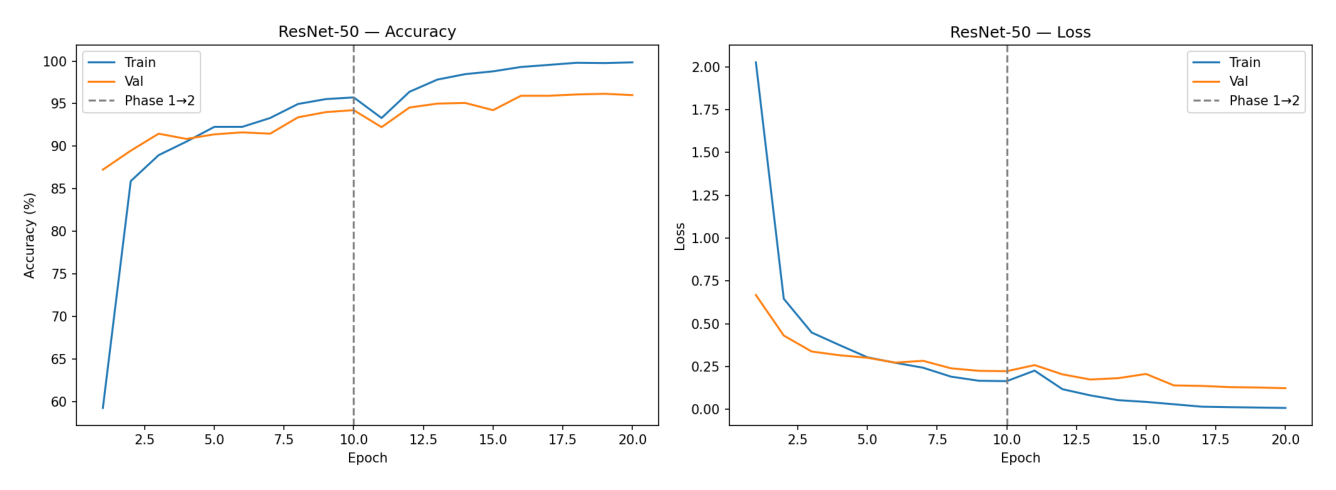

In [31]:
# ── Training Curves ────────────────────────────────────────────────────────
if (FIG_DIR / "resnet_training_curves.png").exists():
    print("Training curves found — loading...")
    img = mpimg.imread(FIG_DIR / "resnet_training_curves.png")
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    epochs = range(1, len(history_resnet["train_acc"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, [a*100 for a in history_resnet["train_acc"]], label="Train")
    ax1.plot(epochs, [a*100 for a in history_resnet["val_acc"]],   label="Val")
    ax1.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
    ax1.set_title("ResNet-50 — Accuracy"); ax1.legend()

    ax2.plot(epochs, history_resnet["train_loss"], label="Train")
    ax2.plot(epochs, history_resnet["val_loss"],   label="Val")
    ax2.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.set_title("ResNet-50 — Loss"); ax2.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "resnet_training_curves.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

In [32]:
# ── Evaluation on Test Set ─────────────────────────────────────────────────
if (MODEL_DIR / "resnet_test_pred.npy").exists():
    print("ResNet predictions found — loading...")
    y_test_pred_resnet = np.load(MODEL_DIR / "resnet_test_pred.npy")
    y_test_true_resnet = np.load(MODEL_DIR / "resnet_test_true.npy")
    y_test_prob_resnet = np.load(MODEL_DIR / "resnet_test_prob.npy")
    print("Loaded ✓")

else:
    print("Running evaluation...")
    resnet.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(DEVICE)
            outputs = resnet(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())

    y_test_pred_resnet = np.concatenate(all_preds)
    y_test_true_resnet = np.concatenate(all_labels)
    y_test_prob_resnet = np.concatenate(all_probs)

    np.save(MODEL_DIR / "resnet_test_pred.npy", y_test_pred_resnet)
    np.save(MODEL_DIR / "resnet_test_true.npy", y_test_true_resnet)
    np.save(MODEL_DIR / "resnet_test_prob.npy", y_test_prob_resnet)
    print("Predictions saved to Drive ✓")

# Metrics — always recompute from predictions (fast)
test_acc = accuracy_score(y_test_true_resnet, y_test_pred_resnet)
top5_acc = top_k_accuracy_score(y_test_true_resnet, y_test_prob_resnet, k=5)

print(f"{'='*50}")
print(f"  ResNet-50 — Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc*100:.2f}%")
print(f"  Top-5 Accuracy   : {top5_acc*100:.2f}%")
print(f"\n{'─'*50}")
print(classification_report(
    y_test_true_resnet, y_test_pred_resnet,
    target_names=le.classes_, digits=3, zero_division=0
))

ResNet predictions found — loading...
Loaded ✓
  ResNet-50 — Test Results
  Overall Accuracy : 96.08%
  Top-5 Accuracy   : 99.54%

──────────────────────────────────────────────────
                 precision    recall  f1-score   support

          Faces      0.985     1.000     0.992        66
     Faces_easy      1.000     0.985     0.992        66
       Leopards      1.000     1.000     1.000        30
     Motorbikes      1.000     1.000     1.000       120
      accordion      1.000     1.000     1.000         8
      airplanes      1.000     1.000     1.000       120
         anchor      1.000     1.000     1.000         6
            ant      0.714     0.833     0.769         6
         barrel      1.000     1.000     1.000         7
           bass      1.000     1.000     1.000         8
         beaver      1.000     0.429     0.600         7
      binocular      1.000     1.000     1.000         5
         bonsai      0.950     1.000     0.974        19
          brain    

Confusion matrix found — loading...


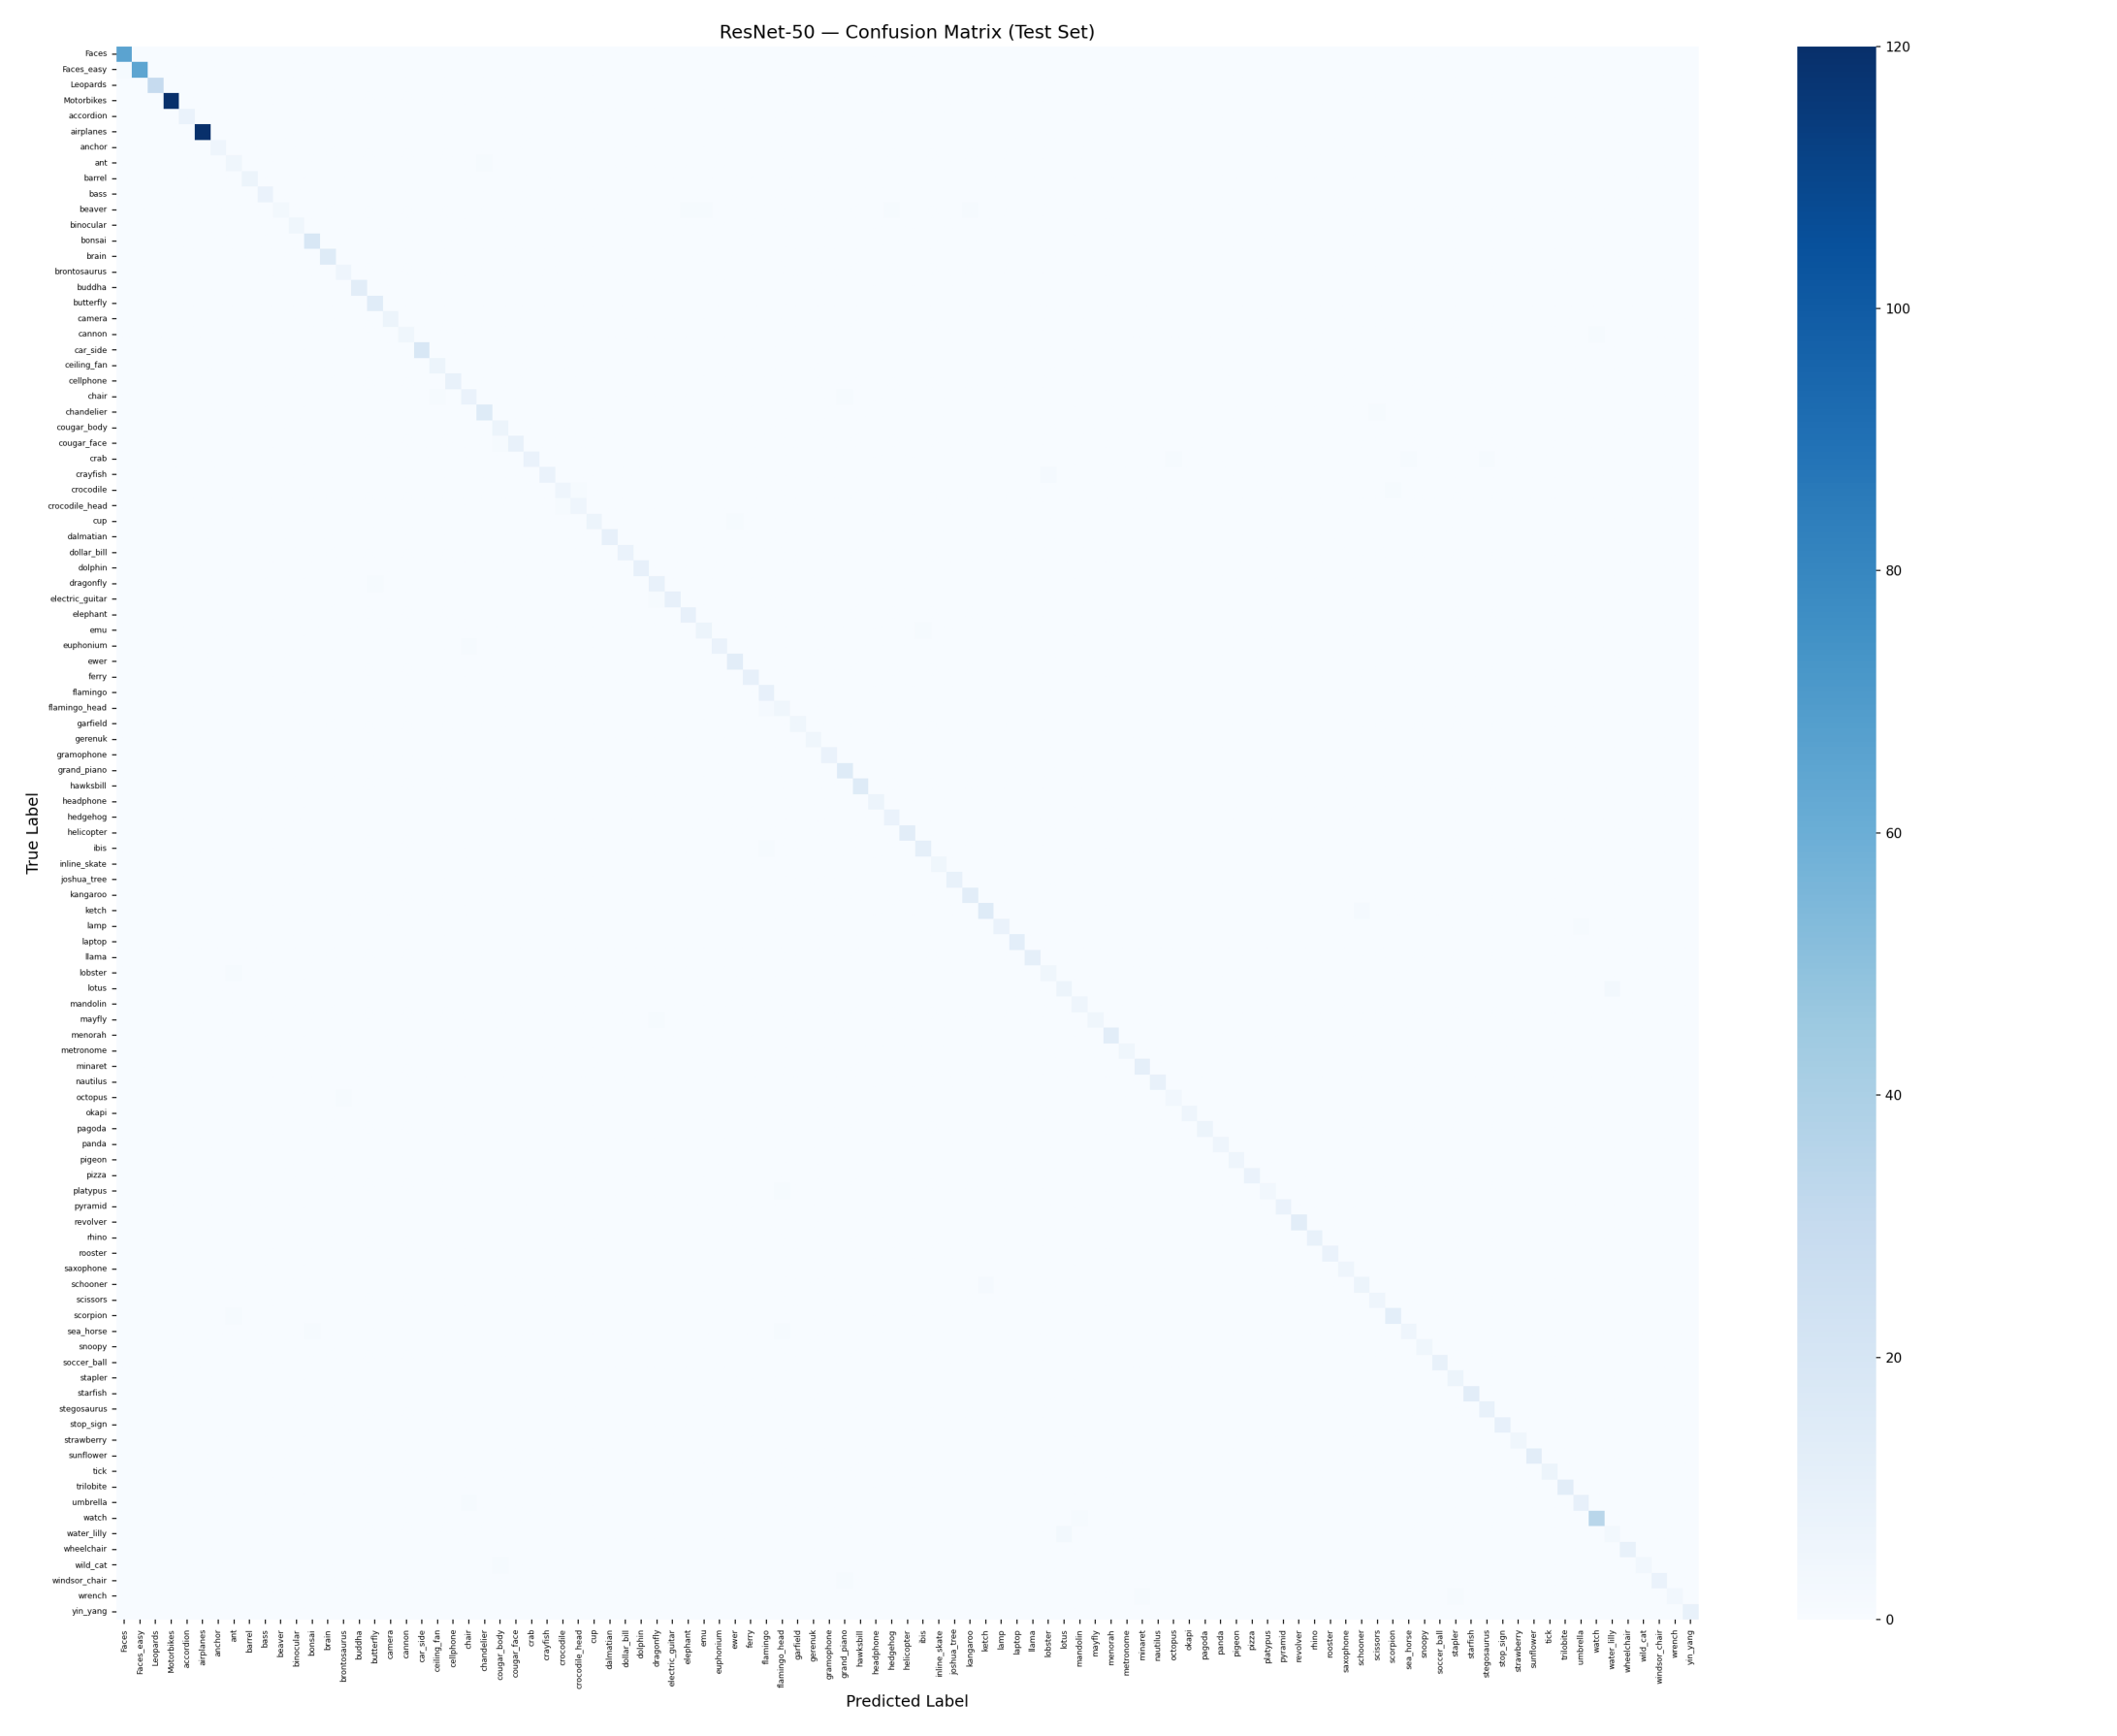

In [33]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
if (FIG_DIR / "resnet_confusion_matrix.png").exists():
    print("Confusion matrix found — loading...")
    img = mpimg.imread(FIG_DIR / "resnet_confusion_matrix.png")
    fig, ax = plt.subplots(figsize=(22, 18))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    cm_resnet = confusion_matrix(y_test_true_resnet, y_test_pred_resnet)

    fig, ax = plt.subplots(figsize=(22, 18))
    sns.heatmap(cm_resnet, annot=False, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title("ResNet-50 — Confusion Matrix (Test Set)", fontsize=14)
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0,  fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "resnet_confusion_matrix.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

Per-class accuracy figure found — loading...


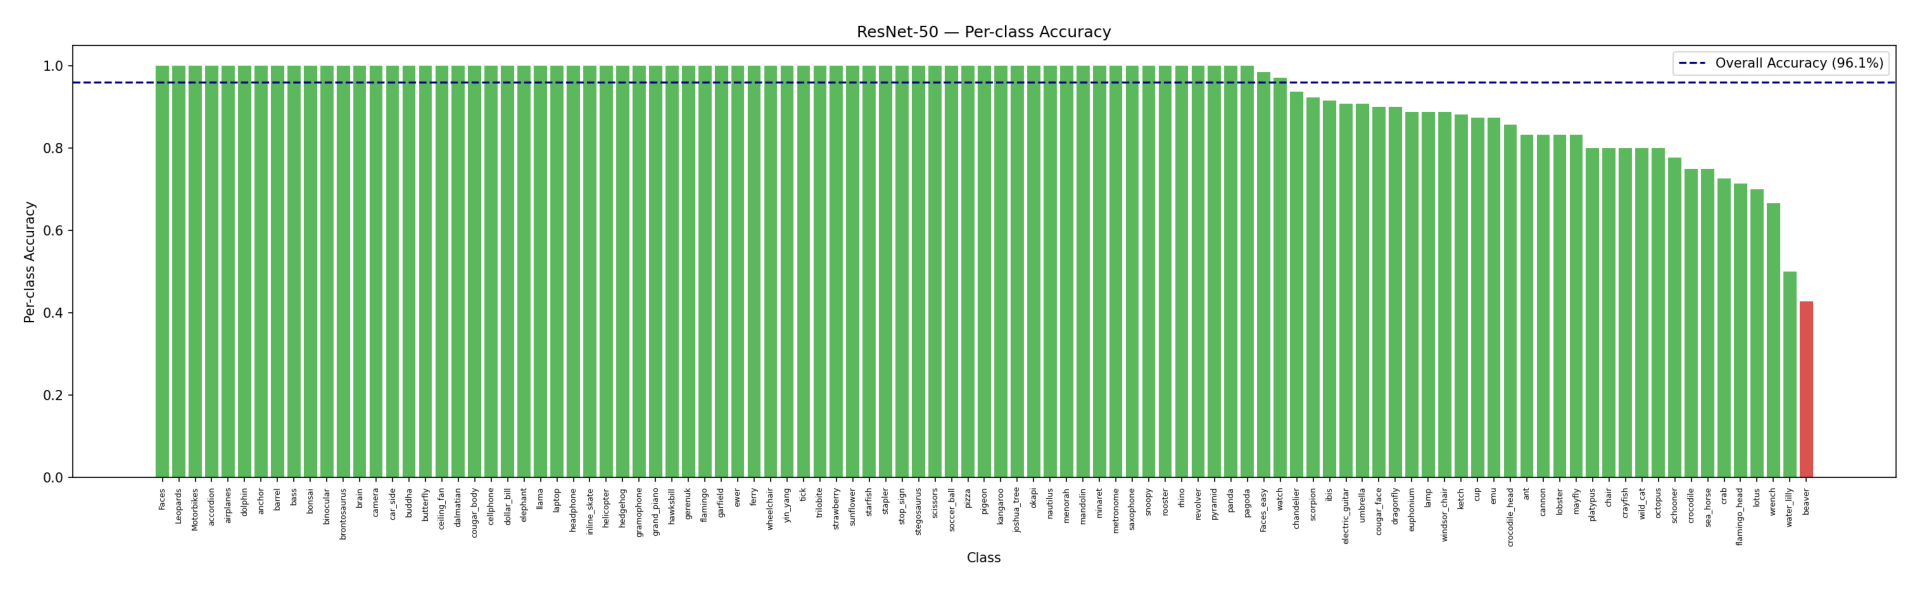

In [34]:
# ── Per-class Accuracy ─────────────────────────────────────────────────────

# Always recompute these (fast, needed for plot)
cm_resnet            = confusion_matrix(y_test_true_resnet, y_test_pred_resnet)
per_class_acc_resnet = cm_resnet.diagonal() / cm_resnet.sum(axis=1)
per_class_df_resnet  = pd.DataFrame({
    "class"        : le.classes_,
    "per_class_acc": per_class_acc_resnet
}).sort_values("per_class_acc", ascending=False)

if (FIG_DIR / "resnet_per_class_accuracy.png").exists():
    print("Per-class accuracy figure found — loading...")
    img = mpimg.imread(FIG_DIR / "resnet_per_class_accuracy.png")
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(20, 6))
    colors = ["#d9534f" if v < 0.5 else "#5cb85c" for v in per_class_df_resnet["per_class_acc"]]
    ax.bar(per_class_df_resnet["class"], per_class_df_resnet["per_class_acc"], color=colors)
    ax.axhline(test_acc, color="navy", linestyle="--", linewidth=1.5,
               label=f"Overall Accuracy ({test_acc*100:.1f}%)")
    ax.set_xlabel("Class"); ax.set_ylabel("Per-class Accuracy")
    ax.set_title("ResNet-50 — Per-class Accuracy")
    ax.legend()
    plt.xticks(rotation=90, fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "resnet_per_class_accuracy.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

## Model 3: Vision Transformer (ViT)

In [35]:
# ── ViT: Setup ────────────────────────────────────────────────────────────
print(f"timm version : {timm.__version__}")
print(f"Using device : {DEVICE}")

timm version : 1.0.25
Using device : mps


In [36]:
# ── Build ViT Model ────────────────────────────────────────────────────────
def build_vit(num_classes, freeze_backbone=True):
    # ViT-Base/16 pretrained on ImageNet-21k then finetuned on ImageNet-1k
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=0          # remove the original head
    )

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Get the embedding dimension (768 for ViT-Base)
    embed_dim = model.num_features

    # Attach our own classification head
    model.head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Dropout(0.5),
        nn.Linear(embed_dim, num_classes)
    )

    return model

vit = build_vit(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

# Count parameters
total     = sum(p.numel() for p in vit.parameters())
trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")   # only the new head

Total params    : 85,877,861
Trainable params: 79,205


In [37]:
# ── Phase 1: Train head only (backbone frozen) ────────────────────────────
criterion_vit = nn.CrossEntropyLoss(label_smoothing=0.1)

if (MODEL_DIR / "vit_phase1.pth").exists():
    print("ViT Phase 1 weights found — loading...")
    vit.load_state_dict(torch.load(MODEL_DIR / "vit_phase1.pth",
                                   map_location=DEVICE))
    history_vit_phase1 = {
        k: list(np.load(MODEL_DIR / f"vit_history_phase1_{k}.npy"))
        for k in ["train_loss", "train_acc", "val_loss", "val_acc"]
    }
    print("Loaded ✓")

else:
    print("Phase 1: Training head only (backbone frozen)...")
    optimizer_vit = optim.Adam(
        filter(lambda p: p.requires_grad, vit.parameters()),
        lr=1e-3
    )
    scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_vit, T_max=10
    )

    vit, history_vit_phase1 = train_model(
        vit, train_loader, val_loader,
        criterion_vit, optimizer_vit, scheduler_vit,
        num_epochs=10
    )

    # Save weights and history
    torch.save(vit.state_dict(), MODEL_DIR / "vit_phase1.pth")
    for k, v in history_vit_phase1.items():
        np.save(MODEL_DIR / f"vit_history_phase1_{k}.npy", v)
    print("Phase 1 saved to Drive ✓")

Phase 1: Training head only (backbone frozen)...
Epoch [01/10] Train Loss: 1.7738  Acc: 76.50%  | Val Loss: 1.0374  Acc: 95.08%  | Time: 322.5s
Epoch [02/10] Train Loss: 1.0592  Acc: 95.11%  | Val Loss: 0.9964  Acc: 96.08%  | Time: 580.7s
Epoch [03/10] Train Loss: 1.0241  Acc: 96.20%  | Val Loss: 0.9919  Acc: 95.93%  | Time: 782.9s
Epoch [04/10] Train Loss: 1.0206  Acc: 96.31%  | Val Loss: 1.0032  Acc: 95.47%  | Time: 241.2s
Epoch [05/10] Train Loss: 1.0230  Acc: 96.81%  | Val Loss: 1.0074  Acc: 94.39%  | Time: 264.6s
Epoch [06/10] Train Loss: 1.0190  Acc: 96.94%  | Val Loss: 0.9912  Acc: 96.16%  | Time: 256.4s
Epoch [07/10] Train Loss: 1.0181  Acc: 97.04%  | Val Loss: 0.9740  Acc: 96.54%  | Time: 263.5s
Epoch [08/10] Train Loss: 1.0052  Acc: 96.99%  | Val Loss: 0.9716  Acc: 96.47%  | Time: 427.9s
Epoch [09/10] Train Loss: 0.9931  Acc: 97.66%  | Val Loss: 0.9630  Acc: 96.70%  | Time: 488.6s
Epoch [10/10] Train Loss: 0.9881  Acc: 97.48%  | Val Loss: 0.9610  Acc: 96.62%  | Time: 278.2s



In [38]:
# ── Phase 2: Unfreeze and fine-tune entire ViT ────────────────────────────
if (MODEL_DIR / "vit_phase2.pth").exists():
    print("ViT Phase 2 weights found — loading...")
    vit.load_state_dict(torch.load(MODEL_DIR / "vit_phase2.pth",
                                   map_location=DEVICE))
    history_vit_phase2 = {
        k: list(np.load(MODEL_DIR / f"vit_history_phase2_{k}.npy"))
        for k in ["train_loss", "train_acc", "val_loss", "val_acc"]
    }
    print("Loaded ✓")

else:
    print("Phase 2: Fine-tuning entire ViT...")

    # Unfreeze all layers
    for param in vit.parameters():
        param.requires_grad = True

    optimizer_vit_ft = optim.AdamW(
        vit.parameters(),
        lr=2e-5,
        weight_decay=0.01
    )
    scheduler_vit_ft = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_vit_ft, T_max=10
    )

    vit, history_vit_phase2 = train_model(
        vit, train_loader, val_loader,
        criterion_vit, optimizer_vit_ft, scheduler_vit_ft,
        num_epochs=10
    )

    # Save weights and history
    torch.save(vit.state_dict(), MODEL_DIR / "vit_phase2.pth")
    for k, v in history_vit_phase2.items():
        np.save(MODEL_DIR / f"vit_history_phase2_{k}.npy", v)
    print("Phase 2 saved to Drive ✓")

# Merge histories — always runs regardless of load or train
history_vit = {
    k: history_vit_phase1[k] + history_vit_phase2[k]
    for k in history_vit_phase1
}

Phase 2: Fine-tuning entire ViT...


KeyboardInterrupt: 

In [ ]:
# ── Final ViT model = vit_phase2.pth (already saved by Phase 2 cell) ──────
# To reload in a new session:
# vit = build_vit(NUM_CLASSES).to(DEVICE)
# vit.load_state_dict(torch.load(MODEL_DIR / "vit_phase2.pth", map_location=DEVICE))
print("Final ViT model is saved as vit_phase2.pth ✓")

In [ ]:
# ── Training Curves ────────────────────────────────────────────────────────
if (FIG_DIR / "vit_training_curves.png").exists():
    print("ViT training curves found — loading...")
    img = mpimg.imread(FIG_DIR / "vit_training_curves.png")
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    epochs = range(1, len(history_vit["train_acc"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, [a*100 for a in history_vit["train_acc"]], label="Train")
    ax1.plot(epochs, [a*100 for a in history_vit["val_acc"]],   label="Val")
    ax1.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
    ax1.set_title("ViT-B/16 — Accuracy"); ax1.legend()

    ax2.plot(epochs, history_vit["train_loss"], label="Train")
    ax2.plot(epochs, history_vit["val_loss"],   label="Val")
    ax2.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.set_title("ViT-B/16 — Loss"); ax2.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "vit_training_curves.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

In [ ]:
# ── Evaluation on Test Set ─────────────────────────────────────────────────
if (MODEL_DIR / "vit_test_pred.npy").exists():
    print("ViT predictions found — loading...")
    y_test_pred_vit = np.load(MODEL_DIR / "vit_test_pred.npy")
    y_test_true_vit = np.load(MODEL_DIR / "vit_test_true.npy")
    y_test_prob_vit = np.load(MODEL_DIR / "vit_test_prob.npy")
    print("Loaded ✓")

else:
    print("Running ViT evaluation...")
    vit.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(DEVICE)
            outputs = vit(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())

    y_test_pred_vit = np.concatenate(all_preds)
    y_test_true_vit = np.concatenate(all_labels)
    y_test_prob_vit = np.concatenate(all_probs)

    np.save(MODEL_DIR / "vit_test_pred.npy", y_test_pred_vit)
    np.save(MODEL_DIR / "vit_test_true.npy", y_test_true_vit)
    np.save(MODEL_DIR / "vit_test_prob.npy", y_test_prob_vit)
    print("Predictions saved to Drive ✓")

# Metrics — always recompute (fast)
test_acc_vit = accuracy_score(y_test_true_vit, y_test_pred_vit)
top5_acc_vit = top_k_accuracy_score(y_test_true_vit, y_test_prob_vit, k=5)

print(f"{'='*50}")
print(f"  ViT-B/16 — Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc_vit*100:.2f}%")
print(f"  Top-5 Accuracy   : {top5_acc_vit*100:.2f}%")
print(f"\n{'─'*50}")
print(classification_report(
    y_test_true_vit, y_test_pred_vit,
    target_names=le.classes_, digits=3, zero_division=0
))

In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────

# Always recompute (fast, needed for per-class accuracy cell below)
cm_vit = confusion_matrix(y_test_true_vit, y_test_pred_vit)

if (FIG_DIR / "vit_confusion_matrix.png").exists():
    print("ViT confusion matrix found — loading...")
    img = mpimg.imread(FIG_DIR / "vit_confusion_matrix.png")
    fig, ax = plt.subplots(figsize=(22, 18))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(22, 18))
    sns.heatmap(cm_vit, annot=False, fmt="d", cmap="Purples",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title("ViT-B/16 — Confusion Matrix (Test Set)", fontsize=14)
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0,  fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "vit_confusion_matrix.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

In [ ]:
# ── Per-class Accuracy ─────────────────────────────────────────────────────

# Always recompute (fast)
cm_vit            = confusion_matrix(y_test_true_vit, y_test_pred_vit)
per_class_acc_vit = cm_vit.diagonal() / cm_vit.sum(axis=1)
per_class_df_vit  = pd.DataFrame({
    "class"        : le.classes_,
    "per_class_acc": per_class_acc_vit
}).sort_values("per_class_acc", ascending=False)

if (FIG_DIR / "vit_per_class_accuracy.png").exists():
    print("ViT per-class accuracy figure found — loading...")
    img = mpimg.imread(FIG_DIR / "vit_per_class_accuracy.png")
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(20, 6))
    colors = ["#d9534f" if v < 0.5 else "#9b59b6" for v in per_class_df_vit["per_class_acc"]]
    ax.bar(per_class_df_vit["class"], per_class_df_vit["per_class_acc"], color=colors)
    ax.axhline(test_acc_vit, color="navy", linestyle="--", linewidth=1.5,
               label=f"Overall Accuracy ({test_acc_vit*100:.1f}%)")
    ax.set_xlabel("Class"); ax.set_ylabel("Per-class Accuracy")
    ax.set_title("ViT-B/16 — Per-class Accuracy")
    ax.legend()
    plt.xticks(rotation=90, fontsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "vit_per_class_accuracy.png", dpi=150)
    plt.show()
    print("Saved to Drive ✓")

In [ ]:
# ── Attention Map Visualization (XAI) ─────────────────────────────────────
def visualize_attention(model, image_tensor, class_name, device=DEVICE):
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)

    attention_maps = []

    def hook_fn(module, input, output):
        attention_maps.append(output.detach().cpu())

    hook = model.blocks[-1].attn.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(img)
    hook.remove()

    attn     = attention_maps[0][0]
    attn     = attn.mean(0)
    cls_attn = attn[0, 1:]

    attn_map = cls_attn.reshape(14, 14).numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    orig = image_tensor.cpu() * std[:, None, None] + mean[:, None, None]
    orig = orig.permute(1, 2, 0).clamp(0, 1).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig);                            axes[0].set_title("Original")
    axes[1].imshow(attn_map, cmap="hot");            axes[1].set_title("Attention Map")
    axes[2].imshow(orig)
    axes[2].imshow(attn_map, cmap="hot", alpha=0.5); axes[2].set_title("Overlay")
    for ax in axes: ax.axis("off")
    plt.suptitle(f"ViT Attention — Class: {class_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"vit_attention_{class_name}.png", dpi=150)
    plt.show()

# Visualize attention for a few test samples
test_dataset = Caltech101Dataset(test_df, dl_transform["val_test"])

for i in range(3):
    img_tensor, label = test_dataset[i]
    class_name = le.classes_[int(label)]    # 🔴 fix: cast to int

    fig_path = FIG_DIR / f"vit_attention_{class_name}.png"

    if fig_path.exists():
        print(f"Attention map for '{class_name}' found — loading...")
        img = mpimg.imread(fig_path)
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.imshow(img)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    else:
        visualize_attention(vit, img_tensor, class_name)
        print(f"Saved attention map for '{class_name}' ✓")